In [1]:
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# statistics (optional but useful)
import scipy as sp
from scipy import stats

In [2]:
import chardet

with open('data_source/bikeshare-ridership-2025/bikeshare_2025_01.csv', 'rb') as f:
    result = chardet.detect(f.read(100000))
    print(result)

{'encoding': 'Windows-1252', 'confidence': 0.73, 'language': ''}


In [3]:
df_jan_25 = pd.read_csv('data_source/bikeshare-ridership-2025/bikeshare_2025_01.csv', 
                          encoding='cp1252')
df_jan_25.head()
df_jan_25.shape
df_jan_25.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202946 entries, 0 to 202945
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Trip_Id             202946 non-null  int64  
 1   Trip_Duration       202946 non-null  int64  
 2   Start_Station_Id    202946 non-null  int64  
 3   Start_Time          202946 non-null  object 
 4   Start_Station_Name  202946 non-null  object 
 5   End_Station_Id      202811 non-null  float64
 6   End_Time            202920 non-null  object 
 7   End_Station_Name    202946 non-null  object 
 8   Bike_Id             202946 non-null  int64  
 9   User_Type           202946 non-null  object 
 10  Bike_Model          202946 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 17.0+ MB


In [4]:
df_jan_25['User_Type'].unique()


array(['Member', 'Casual'], dtype=object)

In [5]:
df_jan_25['Bike_Model'].unique()

array(['ICONIC', 'EFIT G5', 'EFIT'], dtype=object)

In [6]:
import glob

path = 'data_source/bikeshare-ridership-2025/'
files = sorted(glob.glob(path + 'bikeshare_2025_*.csv'))

print(len(files))  # confirm 12 months found

12


In [7]:
for f in files:
    temp = pd.read_csv(f, encoding='cp1252', nrows=5)  # just read 5 rows, fast check
    print(f, '->', list(temp.columns))

data_source/bikeshare-ridership-2025/bikeshare_2025_01.csv -> ['Trip_Id', 'Trip_Duration', 'Start_Station_Id', 'Start_Time', 'Start_Station_Name', 'End_Station_Id', 'End_Time', 'End_Station_Name', 'Bike_Id', 'User_Type', 'Bike_Model']
data_source/bikeshare-ridership-2025/bikeshare_2025_02.csv -> ['Trip_Id', 'Trip_Duration', 'Start_Station_Id', 'Start_Time', 'Start_Station_Name', 'End_Station_Id', 'End_Time', 'End_Station_Name', 'Bike_Id', 'User_Type', 'Bike_Model']
data_source/bikeshare-ridership-2025/bikeshare_2025_03.csv -> ['Trip_Id', 'Trip_Duration', 'Start_Station_Id', 'Start_Time', 'Start_Station_Name', 'End_Station_Id', 'End_Time', 'End_Station_Name', 'Bike_Id', 'User_Type', 'Bike_Model']
data_source/bikeshare-ridership-2025/bikeshare_2025_04.csv -> ['Trip_Id', 'Trip_Duration', 'Start_Station_Id', 'Start_Time', 'Start_Station_Name', 'End_Station_Id', 'End_Time', 'End_Station_Name', 'Bike_Id', 'User_Type', 'Bike_Model']
data_source/bikeshare-ridership-2025/bikeshare_2025_05.csv -

In [8]:
df_2025 = [pd.read_csv(f, encoding='cp1252') for f in files]
df_25 = pd.concat(df_2025, ignore_index=True)

print(df_25.shape)
df_25.info()

(7812520, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7812520 entries, 0 to 7812519
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Trip_Id             int64  
 1   Trip_Duration       int64  
 2   Start_Station_Id    float64
 3   Start_Time          object 
 4   Start_Station_Name  object 
 5   End_Station_Id      float64
 6   End_Time            object 
 7   End_Station_Name    object 
 8   Bike_Id             int64  
 9   User_Type           object 
 10  Bike_Model          object 
dtypes: float64(2), int64(3), object(6)
memory usage: 655.7+ MB


In [9]:
df_25['Start_Station_Id'].isna().sum()

7

In [10]:
df_25['End_Station_Id'].isna().sum()

6761

In [11]:
df_25['End_Time'].isna().sum()

1092

In [12]:
df_25.isna().sum()


Trip_Id                  0
Trip_Duration            0
Start_Station_Id         7
Start_Time               0
Start_Station_Name       7
End_Station_Id        6761
End_Time              1092
End_Station_Name       924
Bike_Id                  0
User_Type                0
Bike_Model               0
dtype: int64

In [13]:
df_25.duplicated().sum()

0

In [14]:
df_25['Trip_Id'].duplicated().sum()  # Trip_Id should be unique

0

In [15]:
df_25[df_25['Start_Station_Id'].isna()]

,Trip_Id,Trip_Duration,Start_Station_Id,Start_Time,Start_Station_Name,End_Station_Id,End_Time,End_Station_Name,Bike_Id,User_Type,Bike_Model
5409066,40954646,40,NaN,2025-09-08 13:46:28,NaN,NaN,2025-09-08 13:47:08,NaN,10618,Member,ICONIC
5409646,40956135,11,NaN,2025-09-08 14:37:50,NaN,NaN,2025-09-08 14:38:01,NaN,10618,Member,ICONIC
5409997,40956146,5,NaN,2025-09-08 14:38:09,NaN,NaN,2025-09-08 14:38:14,NaN,10618,Member,ICONIC
5410513,40956155,77,NaN,2025-09-08 14:38:23,NaN,NaN,2025-09-08 14:39:40,NaN,10618,Member,ICONIC
5507074,41065430,17,NaN,2025-09-10 22:43:28,NaN,NaN,2025-09-10 22:43:45,NaN,8534,Member,EFIT
5507462,41065464,6,NaN,2025-09-10 22:44:52,NaN,NaN,2025-09-10 22:44:58,NaN,8534,Member,EFIT
5924410,41541544,14,NaN,2025-09-22 16:32:42,NaN,NaN,2025-09-22 16:32:56,NaN,10618,Member,ICONIC


In [16]:
df_25[df_25['End_Station_Id'].isna()].head(10)


,Trip_Id,Trip_Duration,Start_Station_Id,Start_Time,Start_Station_Name,End_Station_Id,End_Time,End_Station_Name,Bike_Id,User_Type,Bike_Model
190,34637838,1138,7432.0,2025-01-01 00:47:02,Frederick St / King St E,NaN,2025-01-01 01:06:00,Frederick St / King St E,212,Casual,ICONIC
692,34638383,0,7770.0,2025-01-01 03:47:06,Spadina Ave / Sullivan St,NaN,NaN,Spadina Ave / Sullivan St,2212,Casual,ICONIC
1325,34639326,0,7660.0,2025-01-01 12:13:38,285 Victoria St,NaN,2025-01-01 12:13:38,285 Victoria St,2249,Member,ICONIC
2264,34640716,0,7043.0,2025-01-01 16:13:01,Queens Quay W / Lower Simcoe St,NaN,NaN,Queens Quay W / Lower Simcoe St,646,Casual,ICONIC
2914,34641136,0,7416.0,2025-01-01 17:14:21,Spadina Ave / Blue Jays Way,NaN,2025-01-01 17:14:21,Spadina Ave / Blue Jays Way,4764,Casual,ICONIC
3279,34641638,0,7164.0,2025-01-01 18:39:58,Gould St / Yonge St (TMU),NaN,NaN,Gould St / Yonge St (TMU),189,Member,ICONIC
3828,34642124,0,7037.0,2025-01-01 20:46:28,Bathurst St / Dundas St W,NaN,NaN,Bathurst St / Dundas St W,4157,Member,ICONIC
6465,34645747,0,7239.0,2025-01-02 12:42:49,Bloor St W / Manning Ave - SMART,NaN,2025-01-02 12:42:49,Bloor St W / Manning Ave - SMART,795,Member,ICONIC
10945,34650796,0,7272.0,2025-01-03 00:34:09,Yonge St / Dundonald St,NaN,2025-01-03 00:34:09,Yonge St / Dundonald St,407,Member,ICONIC
15280,34655689,0,7235.0,2025-01-03 16:09:32,Bay St / College St (West Side) - SMART,NaN,2025-01-03 16:09:32,Bay St / College St (West Side) - SMART,7322,Member,ICONIC


In [17]:
# check trip duration distribution for rows with null End_Station_Id
df_25[df_25['End_Station_Id'].isna()]['Trip_Duration'].describe()

count      6761.000000
mean       1855.545777
std        8536.544932
min           0.000000
25%           0.000000
50%         351.000000
75%        1142.000000
max      151037.000000
Name: Trip_Duration, dtype: float64

In [18]:
df_25[df_25['End_Station_Id'].isna()]['Bike_Model'].value_counts()

Bike_Model
ICONIC     5432
EFIT        957
EFIT G5     372
Name: count, dtype: int64

In [19]:
null_rows = df_25[df_25['End_Station_Id'].isna()]
(null_rows['Start_Station_Name'] == null_rows['End_Station_Name']).value_counts()

True     5837
False     924
Name: count, dtype: int64

In [20]:
zero_duration = df_25[(df_25['End_Station_Id'].isna()) & (df_25['Trip_Duration'] == 0)]
print(f"Zero duration nulls: {len(zero_duration)}")

normal_duration = df_25[(df_25['End_Station_Id'].isna()) & (df_25['Trip_Duration'] > 0)]
print(f"Non-zero duration nulls: {len(normal_duration)}")

Zero duration nulls: 2986
Non-zero duration nulls: 3775


In [21]:
normal_duration['End_Time'].isna().sum()

0

In [22]:
# Document the pattern found, but don't modify data yet
zero_duration_nulls = ((df_25['Trip_Duration'] == 0) & (df_25['End_Station_Id'].isna())).sum()
print(f"Zero-duration failed trips: {zero_duration_nulls}")

Zero-duration failed trips: 2986


In [23]:
real_trips_missing_end = ((df_25['Trip_Duration'] > 0) & (df_25['End_Station_Id'].isna())).sum()
print(f"Real trips missing End_Station_Id: {real_trips_missing_end}")


Real trips missing End_Station_Id: 3775


In [24]:
df_25.describe()
df_25['User_Type'].value_counts()
df_25['Bike_Model'].value_counts()

Bike_Model
ICONIC     6298758
EFIT       1024014
EFIT G5     489748
Name: count, dtype: int64

In [25]:
import chardet

with open('data_source/bikeshare-ridership-2024.csv', 'rb') as f:
    result = chardet.detect(f.read(100000))
    print(result)

{'encoding': 'ascii', 'confidence': 1.0, 'language': ''}


In [26]:
df_24 = pd.read_csv('data_source/bikeshare-ridership-2024.csv')

df_24.shape
df_24.info()
df_24.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6953094 entries, 0 to 6953093
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Trip_Id             int64  
 1   Trip_Duration       int64  
 2   Start_Station_Id    int64  
 3   Start_Time          object 
 4   Start_Station_Name  object 
 5   End_Station_Id      float64
 6   End_Time            object 
 7   End_Station_Name    object 
 8   Bike_Id             int64  
 9   User_Type           object 
 10  Bike_Model          object 
dtypes: float64(1), int64(4), object(6)
memory usage: 583.5+ MB


,Trip_Id,Trip_Duration,Start_Station_Id,Start_Time,Start_Station_Name,End_Station_Id,End_Time,End_Station_Name,Bike_Id,User_Type,Bike_Model
0,26682740,528,7041,2024-01-01 00:00:08,Edward St / Yonge St,7130.0,2024-01-01 00:08:56,Davenport Rd / Bedford Rd,7855,Casual,EFIT G5
1,26682742,1924,7245,2024-01-01 00:02:04,Tecumseth St / Queen St W - SMART,7259.0,2024-01-01 00:34:08,Lower Spadina Ave / Lake Shore Blvd W,2453,Casual,ICONIC
2,26682743,2741,7052,2024-01-01 00:03:25,Wellington St W / Bay St,7366.0,2024-01-01 00:49:06,Fort York Blvd / Bathurst St - SMART,7332,Member,ICONIC
3,26682744,353,7041,2024-01-01 00:03:39,Edward St / Yonge St,7418.0,2024-01-01 00:09:32,College Park - Yonge St Entrance,782,Member,ICONIC
4,26682746,2118,7721,2024-01-01 00:04:44,Widmer St / King St W,7721.0,2024-01-01 00:40:02,Widmer St / King St W,1008,Member,ICONIC


In [27]:
print(list(df_24.columns))
print(list(df_25.columns))

set(df_24.columns) == set(df_25.columns)

['Trip_Id', 'Trip_Duration', 'Start_Station_Id', 'Start_Time', 'Start_Station_Name', 'End_Station_Id', 'End_Time', 'End_Station_Name', 'Bike_Id', 'User_Type', 'Bike_Model']
['Trip_Id', 'Trip_Duration', 'Start_Station_Id', 'Start_Time', 'Start_Station_Name', 'End_Station_Id', 'End_Time', 'End_Station_Name', 'Bike_Id', 'User_Type', 'Bike_Model']


True

In [28]:
df_24.isna().sum()

Trip_Id                  0
Trip_Duration            0
Start_Station_Id         0
Start_Time               0
Start_Station_Name       0
End_Station_Id        8424
End_Time              5822
End_Station_Name      8424
Bike_Id                  0
User_Type                0
Bike_Model               0
dtype: int64

In [29]:
df_24.duplicated().sum()
df_24['Trip_Id'].duplicated().sum()

0

In [30]:
zero_duration_24 = ((df_24['Trip_Duration'] == 0) & (df_24['End_Station_Id'].isna())).sum()
print(f"Zero-duration failed trips (2024): {zero_duration_24}")

real_trips_missing_end_24 = ((df_24['Trip_Duration'] > 0) & (df_24['End_Station_Id'].isna())).sum()
print(f"Real trips missing End_Station_Id (2024): {real_trips_missing_end_24}")

Zero-duration failed trips (2024): 5044
Real trips missing End_Station_Id (2024): 3380


In [31]:
df_24['Year'] = 2024
df_25['Year'] = 2025

df_all = pd.concat([df_24, df_25], ignore_index=True)

print(df_all.shape)  # should be ~14,765,614
df_all.info()

(14765614, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14765614 entries, 0 to 14765613
Data columns (total 12 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Trip_Id             int64  
 1   Trip_Duration       int64  
 2   Start_Station_Id    float64
 3   Start_Time          object 
 4   Start_Station_Name  object 
 5   End_Station_Id      float64
 6   End_Time            object 
 7   End_Station_Name    object 
 8   Bike_Id             int64  
 9   User_Type           object 
 10  Bike_Model          object 
 11  Year                int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 1.3+ GB


In [32]:
df_all['Trip_Id'] = pd.to_numeric(df_all['Trip_Id'], downcast='integer')
df_all['Trip_Duration'] = pd.to_numeric(df_all['Trip_Duration'], downcast='integer')
df_all['Bike_Id'] = pd.to_numeric(df_all['Bike_Id'], downcast='integer')
df_all['Year'] = pd.to_numeric(df_all['Year'], downcast='integer')

In [33]:
df_all['Start_Station_Id'] = pd.to_numeric(df_all['Start_Station_Id'], downcast='float')
df_all['End_Station_Id'] = pd.to_numeric(df_all['End_Station_Id'], downcast='float')

In [34]:
df_all['User_Type'] = df_all['User_Type'].astype('category')
df_all['Bike_Model'] = df_all['Bike_Model'].astype('category')
df_all['Start_Station_Name'] = df_all['Start_Station_Name'].astype('category')
df_all['End_Station_Name'] = df_all['End_Station_Name'].astype('category')

In [35]:
df_all['Start_Time'] = pd.to_datetime(df_all['Start_Time'])
df_all['End_Time'] = pd.to_datetime(df_all['End_Time'])

In [36]:
df_all.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14765614 entries, 0 to 14765613
Data columns (total 12 columns):
 #   Column              Dtype         
---  ------              -----         
 0   Trip_Id             int32         
 1   Trip_Duration       int32         
 2   Start_Station_Id    float32       
 3   Start_Time          datetime64[ns]
 4   Start_Station_Name  category      
 5   End_Station_Id      float32       
 6   End_Time            datetime64[ns]
 7   End_Station_Name    category      
 8   Bike_Id             int16         
 9   User_Type           category      
 10  Bike_Model          category      
 11  Year                int16         
dtypes: category(4), datetime64[ns](2), float32(2), int16(2), int32(2)
memory usage: 591.7 MB


In [37]:

df_all['Year'].value_counts()

Year
2025    7812520
2024    6953094
Name: count, dtype: int64

In [38]:
df_all.isna().sum()

Trip_Id                   0
Trip_Duration             0
Start_Station_Id          7
Start_Time                0
Start_Station_Name        7
End_Station_Id        15185
End_Time               6914
End_Station_Name       9348
Bike_Id                   0
User_Type                 0
Bike_Model                0
Year                      0
dtype: int64

In [39]:
df_all.dtypes


Trip_Id                        int32
Trip_Duration                  int32
Start_Station_Id             float32
Start_Time            datetime64[ns]
Start_Station_Name          category
End_Station_Id               float32
End_Time              datetime64[ns]
End_Station_Name            category
Bike_Id                        int16
User_Type                   category
Bike_Model                  category
Year                           int16
dtype: object

In [40]:
df_all['User_Type'].cat.categories
df_all['Bike_Model'].cat.categories

Index(['EFIT', 'EFIT G5', 'ICONIC'], dtype='object')

In [41]:
df_all.memory_usage(deep=True).sort_values(ascending=False) / 1024**2


Start_Time            112.652695
End_Time              112.652695
Trip_Id                56.326347
Trip_Duration          56.326347
Start_Station_Id       56.326347
End_Station_Id         56.326347
End_Station_Name       28.283514
Start_Station_Name     28.283439
Bike_Id                28.163174
Year                   28.163174
Bike_Model             14.081869
User_Type              14.081810
Index                   0.000122
dtype: float64

In [42]:
print(df_all['User_Type'].unique())
print(df_all['Bike_Model'].unique())

['Casual', 'Member']
Categories (2, object): ['Casual', 'Member']
['EFIT G5', 'ICONIC', 'EFIT']
Categories (3, object): ['EFIT', 'EFIT G5', 'ICONIC']


In [43]:
df_all['Trip_Duration'].describe()

count    1.476561e+07
mean     9.671225e+02
std      3.862761e+03
min      0.000000e+00
25%      4.190000e+02
50%      6.760000e+02
75%      1.086000e+03
max      2.487915e+06
Name: Trip_Duration, dtype: float64

In [44]:
# 1. unique values in categorical columns
print(df_all['User_Type'].unique())
print(df_all['Bike_Model'].unique())

['Casual', 'Member']
Categories (2, object): ['Casual', 'Member']
['EFIT G5', 'ICONIC', 'EFIT']
Categories (3, object): ['EFIT', 'EFIT G5', 'ICONIC']


In [45]:
# 2. trip duration outliers
df_all['Trip_Duration'].describe()
(df_all['Trip_Duration'] == 0).sum()
(df_all['Trip_Duration'] > 86400).sum()

879

In [46]:
# 3. date range check
print(df_all['Start_Time'].min())
print(df_all['Start_Time'].max())

2024-01-01 00:00:08
2025-12-31 23:59:49


In [47]:
(df_all['Trip_Duration'] == 0).sum()

16352

In [48]:
df_trips = df_all[df_all['Trip_Duration'] > 0]

✅ 14,765,614 rows — 2 full years
✅ Memory optimized — ~591MB
✅ Dtypes correct
✅ Categorical columns clean
✅ Date range verified — Jan 2024 to Dec 2025
✅ Nulls documented — not dropped
✅ Time features extracted — month, hour, day_of_week, season
✅ Zero duration trips handled — filtered via df_trips
✅ Long trips documented — 879 trips over 24 hours

In [51]:
df_all['month'] = df_all['Start_Time'].dt.month.astype('int8')
df_all['hour'] = df_all['Start_Time'].dt.hour.astype('int8')
df_all['day_of_week'] = df_all['Start_Time'].dt.day_name().astype('category')
df_all['season'] = df_all['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
}).astype('category')

# verify
print(df_all.columns.tolist())
df_all[['month', 'hour', 'day_of_week', 'season']].head()

['Trip_Id', 'Trip_Duration', 'Start_Station_Id', 'Start_Time', 'Start_Station_Name', 'End_Station_Id', 'End_Time', 'End_Station_Name', 'Bike_Id', 'User_Type', 'Bike_Model', 'Year', 'month', 'hour', 'day_of_week', 'season']


,month,hour,day_of_week,season
0,1,0,Monday,Winter
1,1,0,Monday,Winter
2,1,0,Monday,Winter
3,1,0,Monday,Winter
4,1,0,Monday,Winter


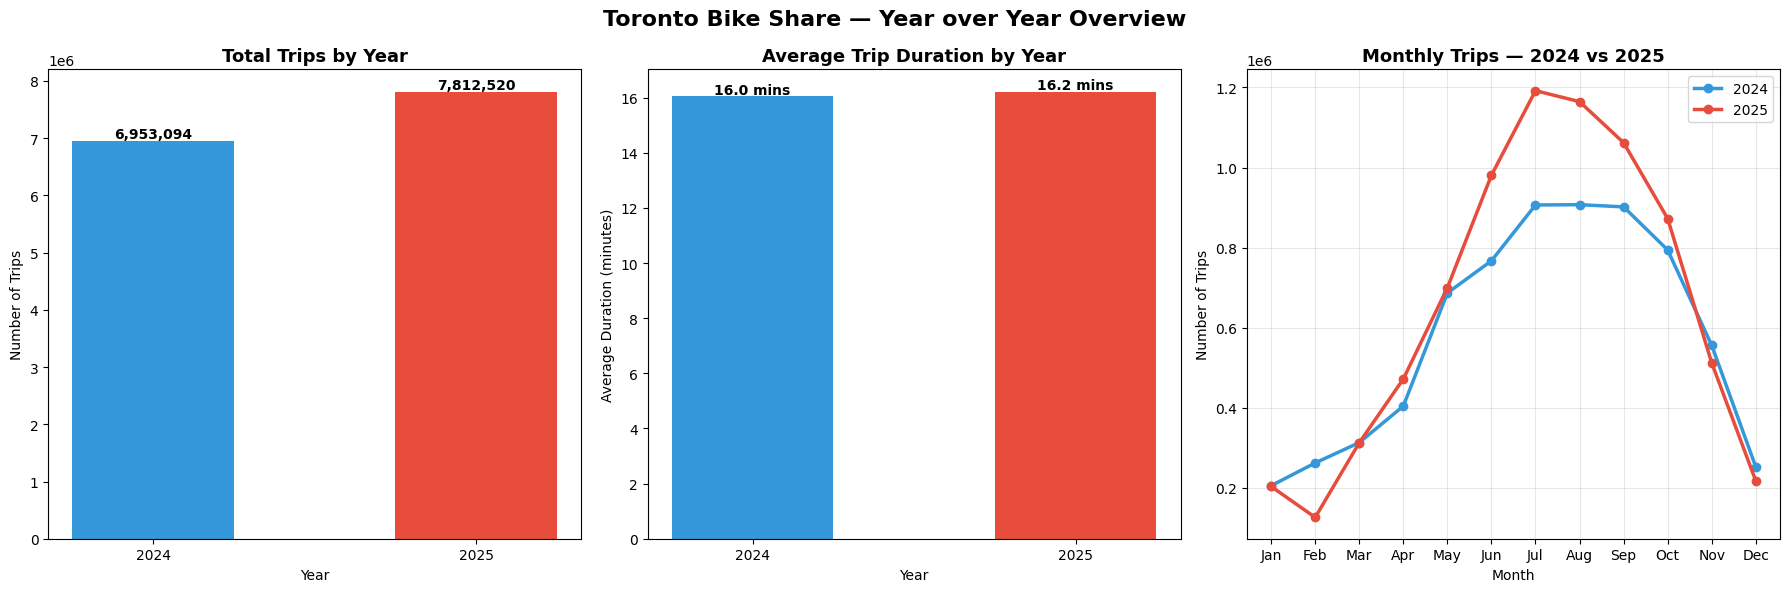

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('visualizations', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── 1. Total trips by year ─────────────────────────────────────
trips_by_year = df_all.groupby('Year').size().reset_index(name='trips')

bars = axes[0].bar(trips_by_year['Year'].astype(str),
                   trips_by_year['trips'],
                   color=['#3498db', '#e74c3c'], width=0.5)
axes[0].set_title('Total Trips by Year', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Trips')
for bar, val in zip(bars, trips_by_year['trips']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50000,
                 f'{val:,.0f}', ha='center',
                 fontsize=10, fontweight='bold')

# ── 2. Average trip duration by year ──────────────────────────
avg_duration = df_trips.groupby('Year')['Trip_Duration'].mean() / 60  # convert to minutes

bars = axes[1].bar(avg_duration.index.astype(str),
                   avg_duration.values,
                   color=['#3498db', '#e74c3c'], width=0.5)
axes[1].set_title('Average Trip Duration by Year',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Duration (minutes)')
for bar, val in zip(bars, avg_duration.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{val:.1f} mins', ha='center',
                 fontsize=10, fontweight='bold')

# ── 3. Trips by month — 2024 vs 2025 ──────────────────────────
trips_by_month = df_all.groupby(['Year', 'month']).size().reset_index(name='trips')

for year, color in [(2024, '#3498db'), (2025, '#e74c3c')]:
    data = trips_by_month[trips_by_month['Year'] == year]
    axes[2].plot(data['month'], data['trips'],
                 color=color, linewidth=2.5,
                 marker='o', markersize=6,
                 label=str(year))

axes[2].set_title('Monthly Trips — 2024 vs 2025',
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Number of Trips')
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.suptitle('Toronto Bike Share — Year over Year Overview',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/year_over_year.png', dpi=150)
plt.show()